<a href="https://colab.research.google.com/github/Ishashaikh29/ISHA_AIDSSEM8_RL_EXP/blob/main/ISARLEXP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ISHA SHAIKH || 221A050 || 47**

Teach a Taxi to pick up and drop off passenger at the right locations with reinforcement learning

# **1.Import dependencies**

In [ ]:
#ISHA SHAIKH || 221A050 || 47
import os
import gymnasium as gym
import numpy as np

# **2.Load environment**

In [ ]:
#ISHA SHAIKH || 221A050 || 47
env=gym.make("Taxi-v3", render_mode='rgb_array')

In [ ]:
#ISHA SHAIKH || 221A050 || 47
state=env.reset()

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
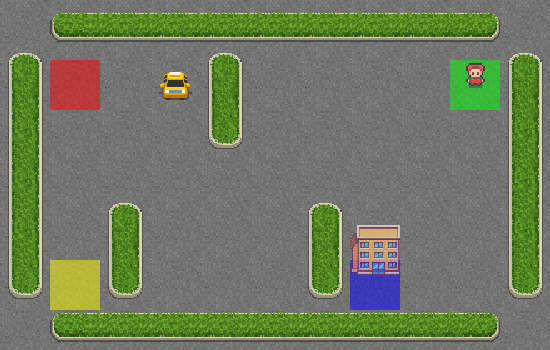

In [ ]:
env.render()

In [ ]:
#ISHA SHAIKH || 221A050 || 47
state

342

In [ ]:
#ISHA SHAIKH || 221A050 || 47
env.observation_space.n

np.int64(500)

In [ ]:
#ISHA SHAIKH || 221A050 || 47
env.action_space.n

np.int64(6)

In [ ]:
#ISHA SHAIKH || 221A050 || 47
env.observation_space.n

500

# **3.Possible Actions**

down(0),up(1),right(2),left(3),pickup(4),drop-off(5)

In [ ]:
#ISHA SHAIKH || 221A050 || 47
n_states=env.observation_space.n
n_actions=env.action_space.n

In [ ]:
#ISHA SHAIKH || 221A050 || 47
print(n_actions)

6


In [ ]:
#ISHA SHAIKH || 221A050 || 47
print(n_states)

500


In [ ]:
#ISHA SHAIKH || 221A050 || 47
env.step(1)


(27,
 -1,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([1, 0, 0, 1, 0, 0], dtype=int8)})

# **4.How good does behaving completely random do?**

In [ ]:
#ISHA SHAIKH || 221A050 || 47
state=env.reset()
counter=0
g=0
reward=None

In [ ]:
#ISHA SHAIKH || 221A050 || 47
while reward !=20:
    state2, reward, terminated, truncated, info = env.step(env.action_space.sample())
    done = terminated or truncated
    counter+=1
    g+=reward
    state=state2

In [ ]:
#ISHA SHAIKH || 221A050 || 47
print("Solved in {} steps with a total reward of {}".format(counter,g))

Solved in 2242 steps with a total reward of -8512


# **5.Let's look at just one episode and see how the Q value changes after each step using the formula**

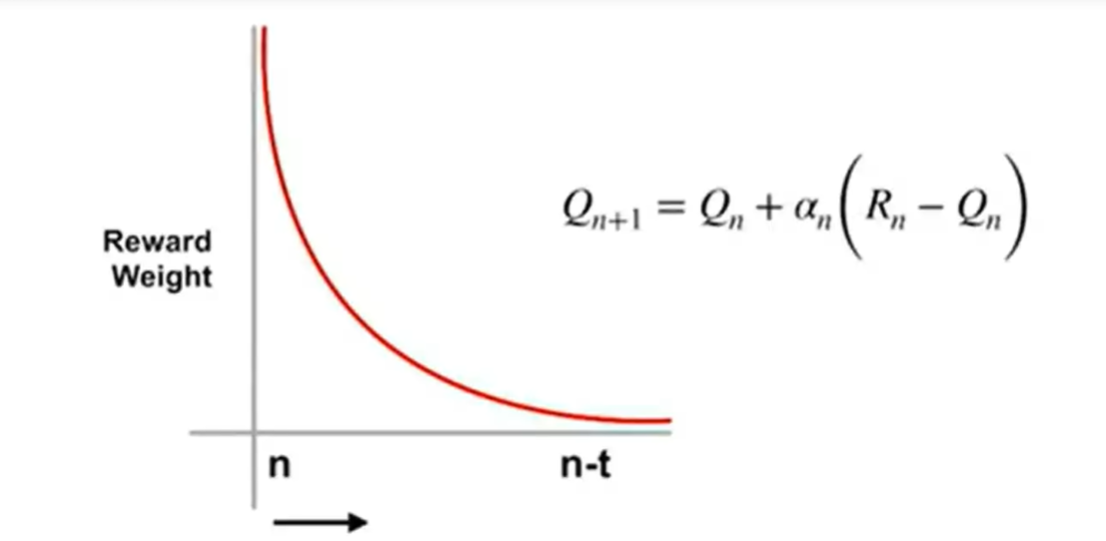

In [ ]:
#ISHA SHAIKH || 221A050 || 47
Q=np.zeros([n_states,n_actions])

In [ ]:
#ISHA SHAIKH || 221A050 || 47
np.shape(Q)

(500, 6)

In [ ]:
#ISHA SHAIKH || 221A050 || 47
n_actions

np.int64(6)

In [ ]:
#ISHA SHAIKH || 221A050 || 47
episodes=1
G=0
aplha=0.618

In [ ]:
#ISHA SHAIKH || 221A050 || 47
for episode in range(1, episodes+1):
  done=False
  G,reward=0,0
  # Extract only the observation (integer state) from env.reset()
  state, info = env.reset()
  finalState=state
  print("Inital State {}".format(state))
  while reward!=20:
    action=np.argmax(Q[state,:])
    # Extract only the observation (integer state) from env.step()
    state2, reward, terminated, truncated, info=env.step(action)
    Q[state, action] = Q[state, action] + aplha*(reward + np.max(Q[state2]) - Q[state, action])
    G+=reward
    state=state2

Inital State 49


In [ ]:
#ISHA SHAIKH || 221A050 || 47
G

-2216

In [ ]:
#ISHA SHAIKH || 221A050 || 47

episodes = 2000
rewardTracker = []

G = 0
alpha = 0.618

for episode in range(1, episodes+1):
  done=False
  G,reward=0,0
  # Extract only the observation (integer state) from env.reset()
  state, info = env.reset()
  finalState=state
  print("Inital State {}".format(state))

  while reward!=20:
    action=np.argmax(Q[state,:])
    # Extract only the observation (integer state) from env.step()
    state2, reward, terminated, truncated, info=env.step(action)
    Q[state, action] = Q[state, action] + alpha * (reward + np.max(Q[state2]) - Q[state, action])
    G+=reward
    state=state2

  if episode % 100 == 0:
    print('Episode {} Total Reward: {}'.format(episode,G))

Inital State 29
Inital State 332
Inital State 463
Inital State 451
Inital State 404
Inital State 354
Inital State 374
Inital State 4
Inital State 262
Inital State 151
Inital State 494
Inital State 284
Inital State 214
Inital State 261
Inital State 433
Inital State 324
Inital State 152
Inital State 187
Inital State 27
Inital State 472
Inital State 407
Inital State 484
Inital State 66
Inital State 486
Inital State 114
Inital State 183
Inital State 6
Inital State 123
Inital State 426
Inital State 301
Inital State 106
Inital State 181
Inital State 211
Inital State 194
Inital State 328
Inital State 468
Inital State 286
Inital State 73
Inital State 243
Inital State 308
Inital State 354
Inital State 202
Inital State 361
Inital State 52
Inital State 312
Inital State 346
Inital State 366
Inital State 433
Inital State 132
Inital State 349
Inital State 234
Inital State 24
Inital State 127
Inital State 454
Inital State 443
Inital State 406
Inital State 192
Inital State 346
Inital State 372
Inital 

In [ ]:
#ISHA SHAIKH || 221A050 || 47

G

11

# WE OBSERVE THAT AFTER 2000 EPISODE THE EXPECTED CUMULATIVE REWARD IS HIGHER THAN ONE EPISODE WHICH IS HIGHER THAN RANDOM EPISODE